# 🔍 Fraud Detection — Exploratory Data Analysis (EDA)
> Dataset : Credit Card Fraud Detection — Kaggle (ULB)

**Objectif :** Comprendre les données, visualiser les patterns, identifier les défis pour la modélisation.

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

FRAUD_COLOR   = '#e74c3c'   # rouge
NORMAL_COLOR  = '#2ecc71'   # vert
NEUTRAL_COLOR = '#3498db'   # bleu

print('✅ Imports OK')

✅ Imports OK


---
## 1. Chargement des données

In [2]:
df = pd.read_csv('../data/creditcard.csv')

print('=' * 50)
print(f'📦 Shape : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'💾 Mémoire : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print('=' * 50)
df.head()

📦 Shape : 284,807 lignes × 31 colonnes
💾 Mémoire : 70.6 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 2. Vue d'ensemble du dataset

In [3]:
# Types des colonnes
print('🔎 Types de colonnes :')
print(df.dtypes.value_counts())
print()

# Valeurs manquantes
missing = df.isnull().sum()
print(f'❌ Valeurs manquantes : {missing.sum()} (total)')
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print('   → Aucune valeur manquante ! Dataset propre.')

print()

# Doublons
duplicates = df.duplicated().sum()
print(f'🔁 Doublons : {duplicates}')

🔎 Types de colonnes :
float64    30
int64       1
Name: count, dtype: int64

❌ Valeurs manquantes : 0 (total)
   → Aucune valeur manquante ! Dataset propre.

🔁 Doublons : 1081


In [4]:
# Statistiques descriptives
print('📊 Statistiques descriptives :')
df[['Time', 'Amount', 'Class']].describe().round(2)

📊 Statistiques descriptives :


,Time,Amount,Class
count,284807.00,284807.00,284807.00
mean,94813.86,88.35,0.00
std,47488.15,250.12,0.04
min,0.00,0.00,0.00
25%,54201.50,5.60,0.00
50%,84692.00,22.00,0.00
75%,139320.50,77.16,0.00
max,172792.00,25691.16,1.00


---
## 3. Déséquilibre des classes (Class Imbalance)

In [5]:
# Comptage
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print('=' * 45)
print('📌 Distribution des classes')
print('=' * 45)
print(f'  Transactions normales (0) : {class_counts[0]:>7,}  ({class_pct[0]:.4f}%)')
print(f'  Transactions fraudeuses (1): {class_counts[1]:>7,}  ({class_pct[1]:.4f}%)')
print(f'  Ratio déséquilibre        : 1 fraude pour {class_counts[0]//class_counts[1]:,} normales')
print('=' * 45)

📌 Distribution des classes
  Transactions normales (0) : 284,315  (99.8273%)
  Transactions fraudeuses (1):     492  (0.1727%)
  Ratio déséquilibre        : 1 fraude pour 577 normales


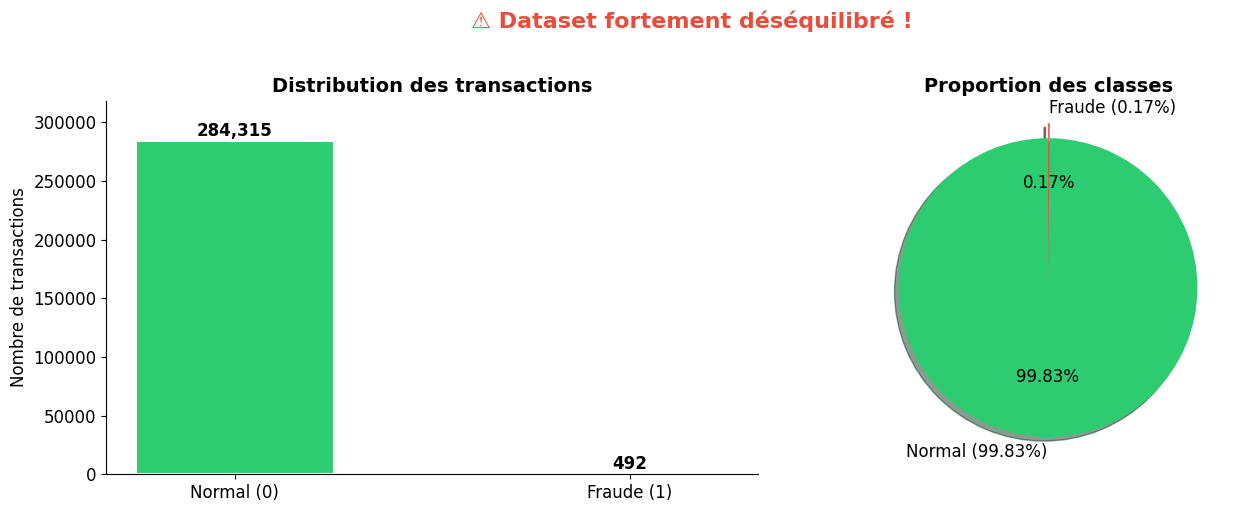

💡 Implication : utiliser SMOTE, class_weight ou AUPRC plutôt que l'accuracy.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Barplot
bars = axes[0].bar(
    ['Normal (0)', 'Fraude (1)'],
    class_counts.values,
    color=[NORMAL_COLOR, FRAUD_COLOR],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribution des transactions', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de transactions')
axes[0].set_ylim(0, class_counts[0] * 1.12)

# -- Pie chart
axes[1].pie(
    class_counts.values,
    labels=['Normal (99.83%)', 'Fraude (0.17%)'],
    colors=[NORMAL_COLOR, FRAUD_COLOR],
    autopct='%1.2f%%',
    startangle=90,
    explode=(0, 0.1),
    shadow=True
)
axes[1].set_title('Proportion des classes', fontsize=14, fontweight='bold')

plt.suptitle('⚠️ Dataset fortement déséquilibré !', fontsize=16, fontweight='bold', color=FRAUD_COLOR, y=1.02)
plt.tight_layout()
plt.savefig('../data/eda_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Implication : utiliser SMOTE, class_weight ou AUPRC plutôt que l\'accuracy.')

---
## 4. Analyse de la variable `Amount`

In [7]:
fraud  = df[df['Class'] == 1]['Amount']
normal = df[df['Class'] == 0]['Amount']

print('💰 Statistiques du montant par classe')
print('-' * 50)
stats_df = pd.DataFrame({
    'Normal': normal.describe(),
    'Fraude': fraud.describe()
}).round(2)
print(stats_df)

💰 Statistiques du montant par classe
--------------------------------------------------
          Normal   Fraude
count  284315.00   492.00
mean       88.29   122.21
std       250.11   256.68
min         0.00     0.00
25%         5.65     1.00
50%        22.00     9.25
75%        77.05   105.89
max     25691.16  2125.87


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -- Histogramme Normal
axes[0, 0].hist(normal.clip(upper=1000), bins=60, color=NORMAL_COLOR, alpha=0.8, edgecolor='white')
axes[0, 0].set_title('Distribution montants — Normal (clipped à 1000€)', fontweight='bold')
axes[0, 0].set_xlabel('Montant (€)')
axes[0, 0].set_ylabel('Fréquence')

# -- Histogramme Fraude
axes[0, 1].hist(fraud.clip(upper=1000), bins=40, color=FRAUD_COLOR, alpha=0.8, edgecolor='white')
axes[0, 1].set_title('Distribution montants — Fraude (clipped à 1000€)', fontweight='bold')
axes[0, 1].set_xlabel('Montant (€)')

# -- Boxplot comparatif
data_box = [normal, fraud]
bp = axes[1, 0].boxplot(data_box, labels=['Normal', 'Fraude'],
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], [NORMAL_COLOR, FRAUD_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_title('Boxplot des montants (log scale)', fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].set_ylabel('Montant (€) — log')

# -- KDE overlay
normal_clip = normal[normal < 500]
fraud_clip  = fraud[fraud < 500]
normal_clip.plot.kde(ax=axes[1, 1], color=NORMAL_COLOR, linewidth=2, label='Normal')
fraud_clip.plot.kde(ax=axes[1, 1], color=FRAUD_COLOR, linewidth=2, label='Fraude')
axes[1, 1].set_title('KDE des montants < 500€', fontweight='bold')
axes[1, 1].set_xlabel('Montant (€)')
axes[1, 1].legend()
axes[1, 1].set_xlim(0, 500)

plt.suptitle('Analyse de la variable Amount', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/eda_amount.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Analyse de la variable `Time`

In [ ]:
# Conversion en heures
df['Hour'] = (df['Time'] / 3600).astype(int) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Distribution temporelle par classe
df[df['Class'] == 0]['Hour'].hist(ax=axes[0], bins=24, color=NORMAL_COLOR,
                                   alpha=0.6, label='Normal', density=True)
df[df['Class'] == 1]['Hour'].hist(ax=axes[0], bins=24, color=FRAUD_COLOR,
                                   alpha=0.8, label='Fraude', density=True)
axes[0].set_title('Distribution temporelle (par heure)', fontweight='bold')
axes[0].set_xlabel('Heure de la journée')
axes[0].set_ylabel('Densité')
axes[0].legend()

# -- Taux de fraude par heure
fraud_rate = df.groupby('Hour')['Class'].mean() * 100
axes[1].bar(fraud_rate.index, fraud_rate.values,
            color=[FRAUD_COLOR if r > fraud_rate.mean() else NEUTRAL_COLOR for r in fraud_rate.values])
axes[1].axhline(fraud_rate.mean(), color='black', linestyle='--', linewidth=1.5,
                label=f'Moyenne : {fraud_rate.mean():.3f}%')
axes[1].set_title('Taux de fraude par heure (%)', fontweight='bold')
axes[1].set_xlabel('Heure de la journée')
axes[1].set_ylabel('Taux de fraude (%)')
axes[1].legend()

plt.suptitle('Analyse temporelle des transactions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/eda_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Les fraudes sont plus fréquentes la nuit (heures creuses de supervision).')

---
## 6. Analyse des features PCA (V1 → V28)

In [ ]:
# Séparation des classes
df_fraud  = df[df['Class'] == 1]
df_normal = df[df['Class'] == 0]
v_features = [f'V{i}' for i in range(1, 29)]

# Test de Student (t-test) pour chaque feature
ttest_results = []
for feat in v_features:
    t_stat, p_val = stats.ttest_ind(df_fraud[feat], df_normal[feat])
    ttest_results.append({'feature': feat, 't_stat': abs(t_stat), 'p_value': p_val})

ttest_df = pd.DataFrame(ttest_results).sort_values('t_stat', ascending=False)
print('Top 10 features les plus discriminantes (t-test) :')
print(ttest_df.head(10).to_string(index=False))

In [ ]:
# -- Barplot des t-stats
plt.figure(figsize=(14, 5))
colors = [FRAUD_COLOR if v > ttest_df['t_stat'].median() else NEUTRAL_COLOR 
          for v in ttest_df.sort_values('feature')['t_stat']]
plt.bar(ttest_df.sort_values('feature')['feature'],
        ttest_df.sort_values('feature')['t_stat'], color=colors)
plt.axhline(ttest_df['t_stat'].median(), color='black', linestyle='--',
            label='Médiane')
plt.title('Pouvoir discriminant de chaque feature PCA (t-statistic)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('|t-statistic|')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../data/eda_ttest.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Top 6 features — KDE fraude vs normal
top_features = ttest_df.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    df_normal[feat].plot.kde(ax=axes[i], color=NORMAL_COLOR, linewidth=2,
                              label='Normal', bw_method=0.3)
    df_fraud[feat].plot.kde(ax=axes[i], color=FRAUD_COLOR, linewidth=2,
                             label='Fraude', bw_method=0.3)
    axes[i].set_title(f'{feat} — Distribution par classe', fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel(feat)
    # Zone de séparation
    axes[i].fill_betweenx(
        axes[i].get_ylim() or [0, 1],
        df_fraud[feat].quantile(0.1),
        df_fraud[feat].quantile(0.9),
        alpha=0.05, color=FRAUD_COLOR
    )

plt.suptitle('Top 6 features les plus discriminantes — KDE Fraude vs Normal',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/eda_top_features_kde.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Matrice de corrélation

In [ ]:
# Corrélation avec la target
corr_with_target = df[v_features + ['Amount', 'Time', 'Class']].corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 8))
colors = [FRAUD_COLOR if c > 0 else NORMAL_COLOR for c in corr_with_target.values]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Corrélation de chaque feature avec la target (Class)',
          fontsize=14, fontweight='bold')
plt.xlabel('Coefficient de corrélation de Pearson')
plt.tight_layout()
plt.savefig('../data/eda_correlation_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Heatmap des inter-corrélations (top 10 features + Amount)
top10 = ttest_df.head(10)['feature'].tolist() + ['Amount']
corr_matrix = df[top10].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # triangle supérieur masqué
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap de corrélation — Top 10 features + Amount',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Les features PCA sont décorrélées entre elles par construction (PCA).')

---
## 8. Outliers dans Amount

In [ ]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[df['Amount'] > upper]
print(f'📊 Outliers Amount (méthode IQR) : {len(outliers):,} transactions')
print(f'   Seuil IQR : > {upper:.2f}€')
print(f'   Dont fraudes dans outliers : {outliers["Class"].sum()}')
print(f'   Taux de fraude parmi outliers : {outliers["Class"].mean()*100:.2f}%')
print(f'   Taux de fraude global : {df["Class"].mean()*100:.4f}%')

---
## 9. Synthèse & Recommandations

In [ ]:
print('''
╔══════════════════════════════════════════════════════════════╗
║          SYNTHÈSE EDA — FRAUD DETECTION                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  📌 DATASET                                                  ║
║    • 284 807 transactions, 492 fraudes (0.17%)              ║
║    • 30 features : Time, Amount + V1..V28 (PCA anonymisée)  ║
║    • Aucune valeur manquante ✅                              ║
║                                                              ║
║  ⚠️ DÉFIS IDENTIFIÉS                                         ║
║    1. Déséquilibre sévère → ne PAS utiliser l\'Accuracy     ║
║       Métrique cible : AUC-PR (Average Precision)           ║
║    2. Amount très asymétrique → log-transform conseillé     ║
║    3. Time à normaliser (pas directement exploitable)       ║
║                                                              ║
║  🎯 TOP FEATURES DISCRIMINANTES                              ║
║    V14, V4, V11, V12, V10, V16 (les plus séparées)         ║
║                                                              ║
║  🛠️ RECOMMANDATIONS POUR LA PHASE 2 (MODÉLISATION)          ║
║    • Scaler Amount + Time (StandardScaler ou RobustScaler)  ║
║    • Stratified Split pour respecter la distribution        ║
║    • SMOTE ou class_weight pour gérer le déséquilibre       ║
║    • Modèles : LogReg → Random Forest → XGBoost → LightGBM ║
║    • Threshold tuning pour optimiser Précision/Rappel       ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
''')

In [ ]:
# Sauvegarde d'un CSV de stats résumées pour la suite
summary = pd.DataFrame({
    'feature': v_features + ['Amount', 'Time'],
    'mean_normal': [df_normal[f].mean() for f in v_features] + 
                   [df_normal['Amount'].mean(), df_normal['Time'].mean()],
    'mean_fraud': [df_fraud[f].mean() for f in v_features] + 
                  [df_fraud['Amount'].mean(), df_fraud['Time'].mean()],
    'std_normal': [df_normal[f].std() for f in v_features] + 
                  [df_normal['Amount'].std(), df_normal['Time'].std()],
    'std_fraud': [df_fraud[f].std() for f in v_features] + 
                 [df_fraud['Amount'].std(), df_fraud['Time'].std()],
    'corr_with_target': [df[f].corr(df['Class']) for f in v_features + ['Amount', 'Time']]
})
summary.to_csv('../data/eda_feature_summary.csv', index=False)
print('✅ Résumé sauvegardé dans data/eda_feature_summary.csv')
print('✅ EDA terminée ! Passe à la Phase 2 : Preprocessing & Modélisation.')